## FilterMags Calculator Tutorial

The purpose of this notebook is to learn how the code in ``filtermag.py`` works using the provided test data from SDSS. 

We have placed example spectra in the ``TestData`` folder and the transmission curves from SDSS in the ``TransmissionCurves`` folder. 

The spectra and curves can be obtained from these sites:

Spectra (from Data Release 19): https://skyserver.sdss.org/dr19/VisualTools/navi

Transmission Curves: https://svo2.cab.inta-csic.es/theory/fps/index.php?mode=browse&gname=SLOAN&asttype=


## What is a transmission curve?
It is essentially a graph telling us what percentage of light passes through a physical filter across different wavelengths. 

These curves quantify what we can see from a telescope. Here is an example of the transmission curves for each filter from SDSS:

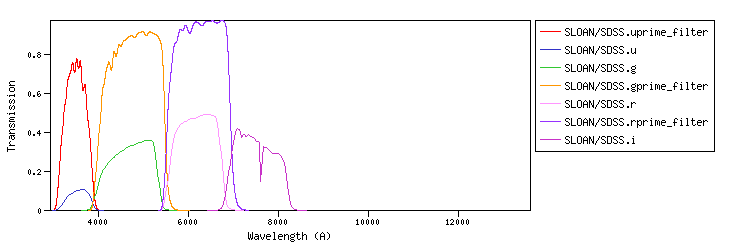

## AB Magnitude System
The monochromatic flux (zero-point flux density) is measured in erg * s^-1 * cm^-2 * Hz^-1 or 3631 Janskys. This means the flux is constant over all filters and does not need 

to be calibrated to a magnitude of a specific star. The SDSS uses the AB magnitude system. The defining equation will be the following:

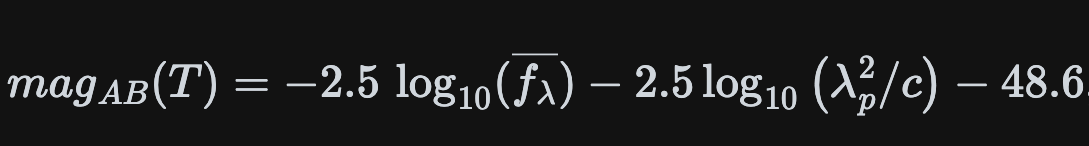

Note: From the calculations, we got the proper units which are in terms of Angstroms NOT Hertz. 

This tutorial will walk you how this code works. It can be broken down into the following steps.

1. The user inputs the transmission curves and extracts the array of values from the data.
2. The user inputs a spectrum and extracts the wavelength and flux.
3. Choose a filter.
4. The code will calculate the AB magnitude.
5. Done!

# Let's begin!

In [12]:
#import necessary packages
import os
from astropy.io import ascii
from astropy.io import fits
import numpy as np

In [13]:
#extract the filter transmission files and put it in a dictionary to call it easier.

current_dir = os.path.abspath("..")

filter_dict = {
    "sdss_u": os.path.join(current_dir, "TransmissionCurves", "SLOAN_SDSS.u.dat"),
    "sdss_g": os.path.join(current_dir, "TransmissionCurves", "SLOAN_SDSS.g.dat"),
    "sdss_r": os.path.join(current_dir, "TransmissionCurves", "SLOAN_SDSS.r.dat"),
    "sdss_i": os.path.join(current_dir, "TransmissionCurves", "SLOAN_SDSS.i.dat"),
    "sdss_z": os.path.join(current_dir, "TransmissionCurves", "SLOAN_SDSS.z.dat"),
}

The example spectrum we will be working with is involving a late stage galactic merger. One is a Seyfert 2 galaxy and has a AGN, the other is a Starburst galaxy! It is at a redshift of 0.04. 

Here a picture of this object: 


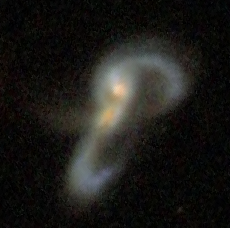

It also has an interesting emission spectrum (which we have the data for in the spec1#.fits file):

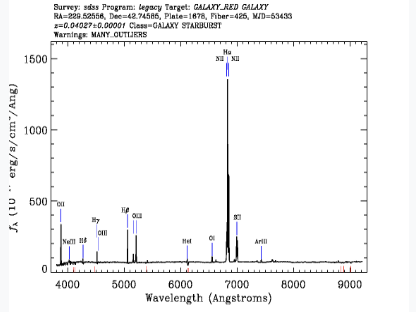


Let's assume we want to see this spectrum through the r-band (~617 nm) filter due to its huge H-alpha line (~646 nm).

In [14]:
#we will create a class that reads the transmission curve
class TransmissionCurve:
    """
    Class that defines transmission curve objects. Each transmission curve has a filter name and arrays of 
    wavelengths and transmission (%) based on the transmission curve files in the repo. The dictionary 
    ``filter_dict`` contains the file names for each filter.
    """
    def __init__(self, filtername):
        """Constructor method
        """
        filename = filter_dict[filtername]
        transmission_data = ascii.read(filename)
        self.wavelength = transmission_data['col1'].data
        self.transmission = transmission_data['col2'].data
        pass

In [15]:
#now let's input the spectrum above!
def read_spectrum(filename):
    """Read SDSS spectrum from FITS

    Function to read an SDSS spectrum from a FITS file.

    Args:
        filename (string): name of the FITS spectrum file

    Returns:
        array, array: wavelength of the spectrum in Angstroms, flux of the spectrum in erg s-1 cm-2 A-1
    """
    spectrum_file = fits.open(filename)
    spectrum_data = spectrum_file[1].data

    wave_spectra = 10**spectrum_data['loglam']
    flux = spectrum_data['flux'] * 1e-17

    spectrum_file.close()

    return wave_spectra, flux

In [16]:
# calculate filter magnitude
def filter_mag(wave_spectra, flux, filter):
    """Filter magnitude calculator

    Calculate the filter magnitude for a spectrum provided by the user in a given filter.
    
    Args: 
        wave_spectra (array): the wavelengths of the spectrum (in Angstroms)
        flux (array): the associated fluxes for the wavelengths (in erg s-1 cm-2 A-1)
        filter (string): the filter that magnitude will be calculated in, identified using a key in ``filter_dict``
    
    Returns: 
        float: filter magnitude for the spectrum
    """
    # read in the transmission curve for the given filter
    trans_curve = TransmissionCurve(filter)
    wave_trans = trans_curve.wavelength
    t = trans_curve.transmission

    if max(wave_spectra) < max(wave_trans) or min(wave_spectra) > min(wave_trans):
        raise ValueError('At least part of filter out of range of spectrum')
    
    # three integrals that are needed for calculation
    int_1 = np.trapezoid(t / wave_trans, wave_trans)
    int_2 = np.trapezoid(t * wave_trans, wave_trans)
    t_spectra = np.interp(wave_spectra, wave_trans, t, left=0, right=0) #interpolation for third integral
    int_3 = np.trapezoid((flux*t_spectra)/wave_spectra, wave_spectra)

    # magnitude calculation
    flam = int_3 / int_1 #f_lambda
    pivot = int_2 / int_1 #pivot wavelength squared
    c = 3e18 #angstrom/s
    mag = -2.5 * np.log10(flam) - 2.5 * np.log10(pivot / c) - 48.6

    return mag

In [19]:
#test the functions
filename = os.path.join(current_dir, "Tutorial", "TestData", "spec1-1678-53433-0425.fits")

wave_spectra, flux = read_spectrum(filename)

mag_r = filter_mag(wave_spectra, flux, "sdss_r")
print("sdss_r:", mag_r)

sdss_r: 16.487188854513484


## This is the magnitude you can see the object through the SDSS r-band filter!

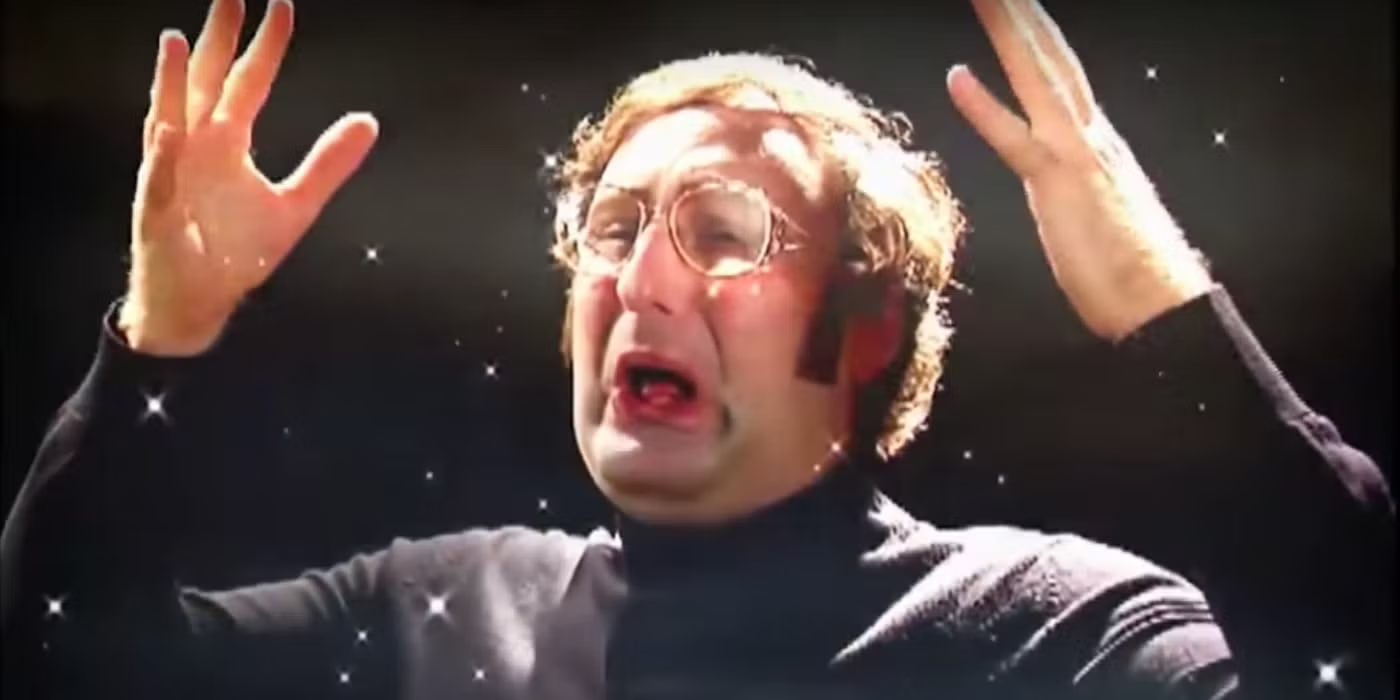